# Data Workflow Project

**Name:** John Laine

**Dataset:** Titanic — Machine Learning from Disaster (Kaggle)

This project implements a reusable end-to-end data workflow for the Titanic passenger dataset. The notebook loads the raw data, applies two reusable cleaning functions to handle missing values and standardize features, runs a structured exploratory analysis function, and produces three labeled visualizations of the survival patterns. The workflow is designed as a foundation that can be extended into a machine learning or deep learning pipeline.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
df = pd.read_csv("./data/titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Cleaning

The raw Titanic dataset has several data quality issues that must be addressed before analysis:

- `Age` is missing for roughly 20% of passengers.
- `Cabin` is missing for roughly 77% of passengers — too sparse to use directly, but the presence/absence of a cabin record is itself informative.
- `Embarked` is missing for a small number of rows.
- `Sex` and `Embarked` are stored as plain strings; converting them to categoricals and expanding the port codes improves readability and downstream modeling.

The two functions below address these issues. Each is written to take a DataFrame and return a cleaned copy (no in-place mutation), so the original `df` remains available for comparison.

In [30]:
def handle_missing_values(df):
    """Return a copy of the Titanic DataFrame with missing values handled.

    Cleaning steps:
        * ``Age``      — imputed with the median age within each
                         (Pclass, Sex) group, since age varies meaningfully
                         by passenger class and sex. Falls back to the
                         overall median for any remaining gaps.
        * ``Embarked`` — imputed with the most common port (mode), since
                         only a handful of rows are missing.
        * ``Cabin``    — too sparse to impute (~77% missing). Replaced with
                         a binary ``HasCabin`` indicator (1 if a cabin was
                         recorded, 0 otherwise), and the original column
                         is dropped.

    Args:
        df: Raw Titanic DataFrame as loaded from ``train.csv``.

    Returns:
        A new DataFrame with no missing values in ``Age`` or ``Embarked``,
        a new ``HasCabin`` column, and ``Cabin`` removed.
    """
    df = df.copy()

    df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
        lambda s: s.fillna(s.median())
    )
    df["Age"] = df["Age"].fillna(df["Age"].median())

    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    df["HasCabin"] = df["Cabin"].notna().astype(int)
    df = df.drop(columns=["Cabin"])

    return df

In [31]:
def standardize_features(df):
    """Return a copy of the DataFrame with standardized types and engineered features.

    Transformations:
        * ``Sex``       — cast to a ``category`` dtype for clarity and lower
                          memory usage.
        * ``Embarked``  — port codes (``C``, ``Q``, ``S``) are expanded to
                          their full names (``Cherbourg``, ``Queenstown``,
                          ``Southampton``) and cast to ``category``.
        * ``Pclass``    — cast to an ordered ``category`` (1st > 2nd > 3rd)
                          so plots and groupings preserve class order.
        * ``FamilySize`` — engineered feature equal to
                           ``SibSp + Parch + 1`` (siblings/spouses plus
                           parents/children plus the passenger themself).
        * ``IsAlone``   — engineered binary flag, 1 when ``FamilySize == 1``.

    Args:
        df: A Titanic DataFrame, typically the output of
            :func:`handle_missing_values`.

    Returns:
        A new DataFrame with standardized categorical columns and two
        additional engineered features.
    """
    df = df.copy()

    df["Sex"] = df["Sex"].astype("category")

    embark_map = {"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"}
    df["Embarked"] = df["Embarked"].map(embark_map).astype("category")

    df["Pclass"] = pd.Categorical(df["Pclass"], categories=[1, 2, 3], ordered=True)

    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    return df

### Apply the cleaning functions

Below the functions are applied in sequence to produce a cleaned DataFrame `df_clean`. A quick check of missing-value counts and dtypes before and after confirms the transformations took effect.

In [32]:
print("Missing values BEFORE cleaning:")
print(df.isna().sum()[df.isna().sum() > 0])

df_clean = standardize_features(handle_missing_values(df))

print("\nMissing values AFTER cleaning:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0] if df_clean.isna().any().any() else "None")

print("\nDtypes after cleaning:")
print(df_clean.dtypes)

df_clean.head()

Missing values BEFORE cleaning:
Age         177
Cabin       687
Embarked      2
dtype: int64

Missing values AFTER cleaning:
None

Dtypes after cleaning:
PassengerId       int64
Survived          int64
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
HasCabin          int64
FamilySize        int64
IsAlone           int64
dtype: object


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Southampton,0,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,Cherbourg,1,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Southampton,0,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,Southampton,1,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Southampton,0,1,1


## Exploratory Data Analysis

With the dataset cleaned, the next step is exploratory analysis. The function below produces a structured snapshot of any DataFrame — shape, dtypes, summary statistics, and survival-rate breakdowns by key categorical features — and a numeric correlation matrix. Packaging this as a function makes the EDA reusable on future slices of the data (e.g., a subset filtered to first-class passengers) without duplicating code.

In [33]:
def explore_dataset(df, target="Survived", group_cols=("Sex", "Pclass", "Embarked", "IsAlone")):
    """Generate a structured exploratory summary of a Titanic-style DataFrame.

    For the supplied DataFrame, this function prints:
        1. Shape (rows, columns) and column dtypes.
        2. ``describe()`` for numeric columns (count, mean, std, quartiles).
        3. Mean of the ``target`` column grouped by each column in
           ``group_cols`` — for the Titanic dataset, this surfaces the
           survival rate within each category (e.g. survival rate by sex,
           by passenger class, etc.).
        4. A Pearson correlation matrix of all numeric columns, useful for
           spotting features that move together with the target.

    Args:
        df: The DataFrame to analyze.
        target: Name of the numeric/binary outcome column to break down by
            each grouping (default ``"Survived"``).
        group_cols: Iterable of categorical columns to use as groupings
            for the target-mean breakdown. Columns not present in ``df``
            are skipped silently so the function works on filtered slices.

    Returns:
        The Pearson correlation matrix (a DataFrame), so the caller can
        reuse it (e.g. to plot a heatmap) without recomputing.
    """
    print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")

    print("Dtypes:")
    print(df.dtypes, "\n")

    print("Numeric summary statistics:")
    print(df.describe(), "\n")

    if target in df.columns:
        for col in group_cols:
            if col in df.columns:
                print(f"Mean {target} by {col}:")
                print(df.groupby(col, observed=True)[target].mean().round(3), "\n")

    numeric_df = df.select_dtypes(include="number")
    corr = numeric_df.corr()
    print("Correlation matrix (numeric columns):")
    print(corr.round(2))

    return corr

In [34]:
corr = explore_dataset(df_clean)

Shape: 891 rows x 14 columns

Dtypes:
PassengerId       int64
Survived          int64
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
HasCabin          int64
FamilySize        int64
IsAlone           int64
dtype: object 

Numeric summary statistics:
       PassengerId    Survived         Age       SibSp       Parch  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838   29.112424    0.523008    0.381594   
std     257.353842    0.486592   13.304424    1.102743    0.806057   
min       1.000000    0.000000    0.420000    0.000000    0.000000   
25%     223.500000    0.000000   21.500000    0.000000    0.000000   
50%     446.000000    0.000000   26.000000    0.000000    0.000000   
75%     668.500000    1.000000   36.000000    1.000000    0.000000   
max     891.000000    

## Visualizations

Three plots are produced below to communicate the most useful patterns in the cleaned data. Each visualization is given a title, labeled axes, and a short interpretation cell explaining what the figure shows.

### Figure 1 — Survival rate by passenger class and sex

This grouped bar chart compares the proportion of passengers who survived within each combination of passenger class and sex. It is designed to surface the well-known "women and children first" effect alongside the strong influence of socioeconomic class on survival.

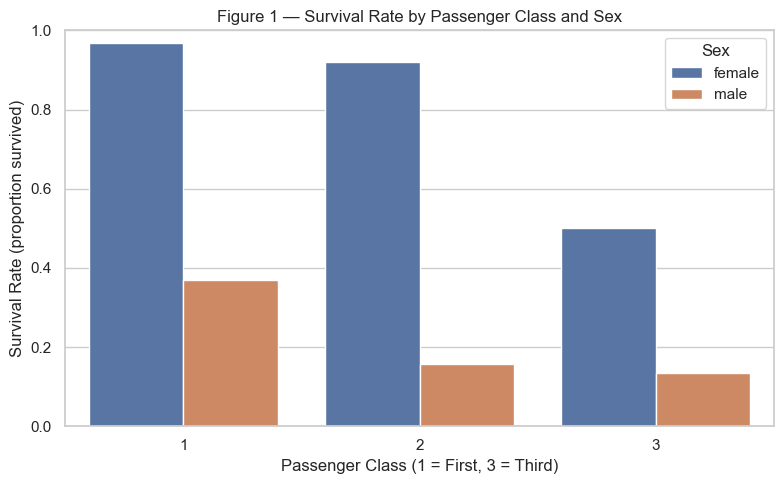

In [35]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=df_clean,
    x="Pclass",
    y="Survived",
    hue="Sex",
    errorbar=None,
    ax=ax,
)
ax.set_title("Figure 1 — Survival Rate by Passenger Class and Sex")
ax.set_xlabel("Passenger Class (1 = First, 3 = Third)")
ax.set_ylabel("Survival Rate (proportion survived)")
ax.set_ylim(0, 1)
ax.legend(title="Sex")
plt.tight_layout()
plt.show()

**Interpretation.** Women survived at far higher rates than men in every class, and within each sex the survival rate falls as class number increases. First-class women had the highest survival rate (close to 1.0), while third-class men had the lowest. Both sex and class are clearly informative features for any predictive model.

### Figure 2 — Age distribution by survival status

This overlaid histogram (with KDE) compares the age distributions of survivors and non-survivors. It is designed to show whether age — particularly being a child — was associated with survival.

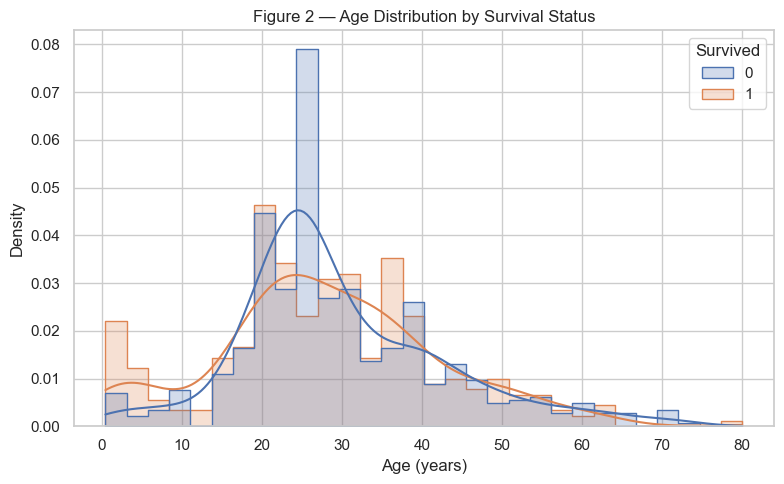

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df_clean,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax,
)
ax.set_title("Figure 2 — Age Distribution by Survival Status")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

**Interpretation.** Survivors are over-represented at the youngest ages — there is a visible bump in the survivor density below roughly age 10 — consistent with children being prioritized in lifeboats. The two distributions overlap heavily through the working-age range, suggesting age alone is a weaker predictor than sex or class, but it still adds signal at the extremes.

### Figure 3 — Correlation heatmap of numeric features

This heatmap visualizes the Pearson correlation matrix computed during EDA. It is designed to show, at a glance, which numeric features move together with `Survived` and which are redundant with each other.

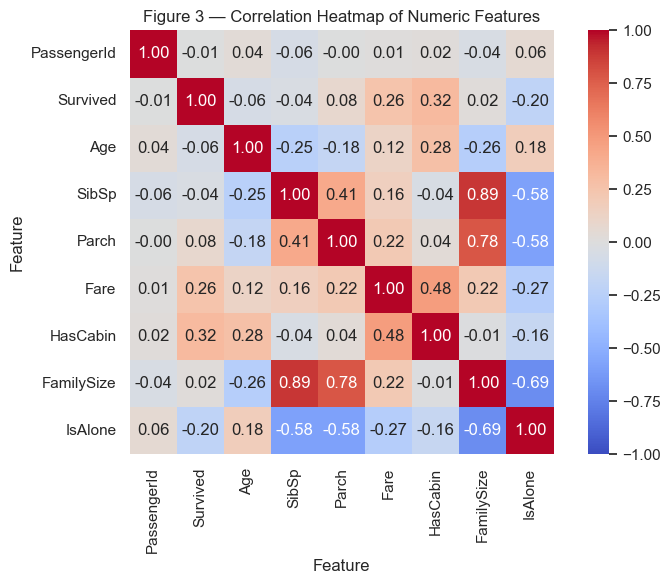

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title("Figure 3 — Correlation Heatmap of Numeric Features")
ax.set_xlabel("Feature")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

**Interpretation.** `Fare` and `HasCabin` show the strongest positive correlations with `Survived`, both consistent with the class effect seen in Figure 1 (wealthier passengers in higher classes paid more, were more likely to have a recorded cabin, and survived more often). `SibSp` and `Parch` correlate strongly with the engineered `FamilySize` (as expected by construction) and `IsAlone` is negatively correlated with `FamilySize` — flagging redundancy that a modeling step would need to address.

## Summary and Interpretation

### What I learned from the dataset

The Titanic training set contains 891 passenger records with a mix of demographic, ticketing, and outcome fields. After cleaning, the dataset is fully usable for analysis: missing `Age` values were imputed within `Pclass`/`Sex` groups, the small number of missing `Embarked` values were filled with the most common port, and the very sparse `Cabin` column was converted into a binary `HasCabin` indicator rather than discarded. The exploratory analysis confirmed that survival on the Titanic was strongly stratified by both social and demographic factors — it was not a random event.

### Interesting patterns and insights

The clearest pattern is the joint effect of sex and passenger class on survival (Figure 1). Women in first class survived at rates near 100%, while men in third class survived at rates closer to 15%. This is consistent with the historical "women and children first" boarding policy combined with the physical layout of the ship, which made it harder for lower-class passengers to reach the lifeboats. Figure 2 shows a smaller but real age effect: children under roughly 10 years old are over-represented among survivors. Figure 3 supports both findings — `Fare` and the engineered `HasCabin` indicator are the strongest numeric correlates of `Survived`, both of which are proxies for passenger class.

### Limitations and assumptions

Several assumptions were baked into the cleaning step and should be made explicit. Imputing `Age` with the within-group median assumes the missing values are missing at random conditional on `Pclass` and `Sex`, which is plausible but not testable from the data alone. Treating the absence of a `Cabin` record as informative assumes the missingness reflects ticketing/recording practices rather than purely random data loss — this is supported by the strong correlation between `HasCabin` and `Survived` but cannot be proven here. The dataset itself is also a limitation: it covers only 891 of the roughly 2,224 people on board, and the sample is the Kaggle training split rather than a complete passenger manifest, so any survival rates reported here are estimates rather than ground truth for the whole ship.

### Anything surprising or unclear

The most surprising finding was how strongly `HasCabin` correlates with survival even after accounting for class — passengers with any cabin record at all survived at noticeably higher rates than those without one. This suggests the missingness in `Cabin` is not neutral; it is itself a signal about a passenger's standing or about how thoroughly their records were maintained. What remains unclear is the role of `Embarked`: survival rates differ across the three ports, but the ports also differ in their class mix, so it is hard to tell from this dataset alone whether port of embarkation is genuinely informative or merely a stand-in for class. Disentangling that would require either a larger dataset or a multivariate model, both of which are out of scope for this workflow.